In [1]:
%matplotlib inline

from Model import Model
from conv2d import Conv2D
from linear import Linear
from relu import Relu
from MaxPool2d import MaxPool2d
from flatten import Flatten
from AdamW import AdamW
from CosineAnnealingLR import CosineAnnealingLR
from CrossEntropyLoss import CrossEntropyLoss
from Dropout import Dropout
from prep_data import *
import torchvision
from torchvision.datasets import CIFAR10
import numpy as np

In [2]:
# train_dataset = torchvision.datasets.MNIST(
#     root="./MNIST/train", train=True,
#     transform=torchvision.transforms.ToTensor(),
#     download=True)
#
# test_dataset = torchvision.datasets.MNIST(
#     root="./MNIST/test", train=False,
#     transform=torchvision.transforms.ToTensor(),
#     download=True)

# X_train_full = np.array([img.numpy().squeeze() for img, _ in train_dataset])
# y_train_full = np.array([label for _, label in train_dataset])
# X_test = np.array([img.numpy().squeeze() for img, _ in test_dataset])
# y_test = np.array([label for _, label in test_dataset])
#
# X_train_full = X_train_full[:, np.newaxis, :, :]
# X_test = X_test[:, np.newaxis, :, :]
# (X_train, y_train), (X_val, y_val) = split_dataset(X_train_full, y_train_full, val_ratio=0.15)

In [3]:
cifar = CIFAR10(root="./data", train=True, download=True)
cifar_test = CIFAR10(root="./data", train=False, download=True)

mean = np.array([0.4914, 0.4822, 0.4465]).reshape(3, 1, 1)
std = np.array([0.2023, 0.1994, 0.2010]).reshape(3, 1, 1)

X_train = np.array([
    np.transpose(np.array(img).astype(np.float32) / 255.0, (2,0,1))
    for img, _ in cifar
])
X_train = (X_train - mean) / std
y_train = np.array([label for _, label in cifar])


X_test = np.array([
    np.transpose(np.array(img).astype(np.float32) / 255.0, (2,0,1))
    for img, _ in cifar_test
])
X_test = (X_test - mean) / std
y_test = np.array([label for _, label in cifar_test])

(X_train, y_train), (X_val, y_val) = split_dataset(X_train, y_train, val_ratio=0.2)

In [4]:
train_loader = DataLoader(X_train, y_train, batch_size=128, shuffle=True)
val_loader = DataLoader(X_val, y_val, batch_size=64, shuffle=False)
test_loader = DataLoader(X_test, y_test, batch_size=64)

In [5]:
# model = Model()
# model.add(Conv2D(1, 8,(3,3)))
# model.add(Relu())
# model.add(MaxPool2d((2,2)))
# model.add(Flatten())
# model.add(Linear(13*13*8,10))

In [6]:
model = Model()

model.add(Conv2D(3, 32, (3,3), padding=1))
model.add(Relu())
model.add(Conv2D(32, 32, (3,3), padding=1))
model.add(Relu())
model.add(MaxPool2d((2,2)))

model.add(Conv2D(32, 64, (3,3), padding=1))
model.add(Relu())
model.add(MaxPool2d((2,2)))

model.add(Flatten())
model.add(Dropout(0.3))
model.add(Linear(4096, 128))
model.add(Relu())
model.add(Dropout(0.3))
model.add(Linear(128, 10))

In [7]:
EPOCHS = 10
optimizer = AdamW(model.parameters(), lr=1e-3)
scheduler = CosineAnnealingLR(optimizer, EPOCHS * len(train_loader))
criterion = CrossEntropyLoss()

arr_of_train_loss = []
arr_of_val_loss = []
arr_of_acc = []
for epoch in range(EPOCHS):
    train_loss = 0
    model.train()
    for x, labels in train_loader:
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, labels)
        train_loss += loss
        dout = criterion.backward()
        model.backward(dout)
        optimizer.step()
        scheduler.step()
    train_loss/=len(train_loader)
    arr_of_train_loss.append(train_loss)

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    for x, labels in val_loader:
        logits = model(x)
        loss = criterion(logits, labels)
        val_loss+=loss

        preds = np.argmax(logits, axis=1)
        val_correct += np.sum(preds == labels)
        val_total += len(labels)
    val_loss /= len(val_loader)
    arr_of_val_loss.append(val_loss)
    val_acc = val_correct / val_total
    arr_of_acc.append(val_acc)

    print(f"Epoch {epoch + 1}/{EPOCHS} | " f"Train Loss: {train_loss:.4f} | " f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")


Epoch 1/10 | Train Loss: 1.8094 | Val Loss: 1.3221 Acc: 0.5388
Epoch 2/10 | Train Loss: 1.3842 | Val Loss: 1.1135 Acc: 0.6132
Epoch 3/10 | Train Loss: 1.2241 | Val Loss: 1.0222 Acc: 0.6501
Epoch 4/10 | Train Loss: 1.1197 | Val Loss: 0.9400 Acc: 0.6747
Epoch 5/10 | Train Loss: 1.0605 | Val Loss: 0.8908 Acc: 0.6887
Epoch 6/10 | Train Loss: 1.0017 | Val Loss: 0.8456 Acc: 0.7069
Epoch 7/10 | Train Loss: 0.9641 | Val Loss: 0.8248 Acc: 0.7129
Epoch 8/10 | Train Loss: 0.9345 | Val Loss: 0.8082 Acc: 0.7203
Epoch 9/10 | Train Loss: 0.9137 | Val Loss: 0.7998 Acc: 0.7225
Epoch 10/10 | Train Loss: 0.9117 | Val Loss: 0.7976 Acc: 0.7231


In [8]:
model.eval()
test_correct = 0
test_total = 0
for x, labels in test_loader:
    logits = model(x)
    preds = np.argmax(logits, axis=1)

    test_correct += np.sum(preds == labels)
    test_total += len(labels)

    if len(correct_examples) < 2 or len(incorrect_examples) < 2:
        for i in range(len(labels)):
            is_correct = preds[i] == labels[i]
            img_denorm = denormalize(x[i])
            if is_correct and len(correct_examples) < 2:
                correct_examples.append((img_denorm, labels[i], preds[i], logits[i]))
            elif not is_correct and len(incorrect_examples) < 2:
                incorrect_examples.append((img_denorm, labels[i], preds[i], logits[i]))
test_acc = test_correct / test_total

print(f"Test Acc: {test_acc:.4f}")

Test Acc: 0.7246


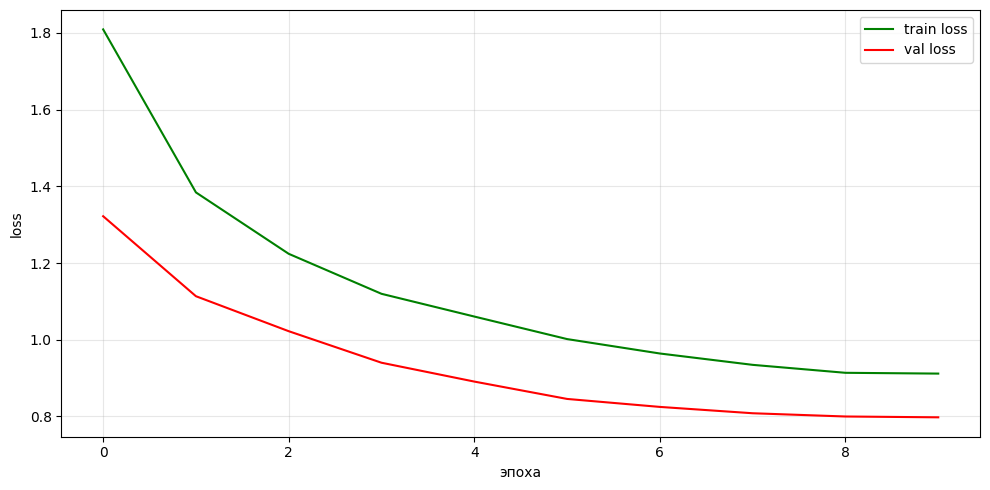

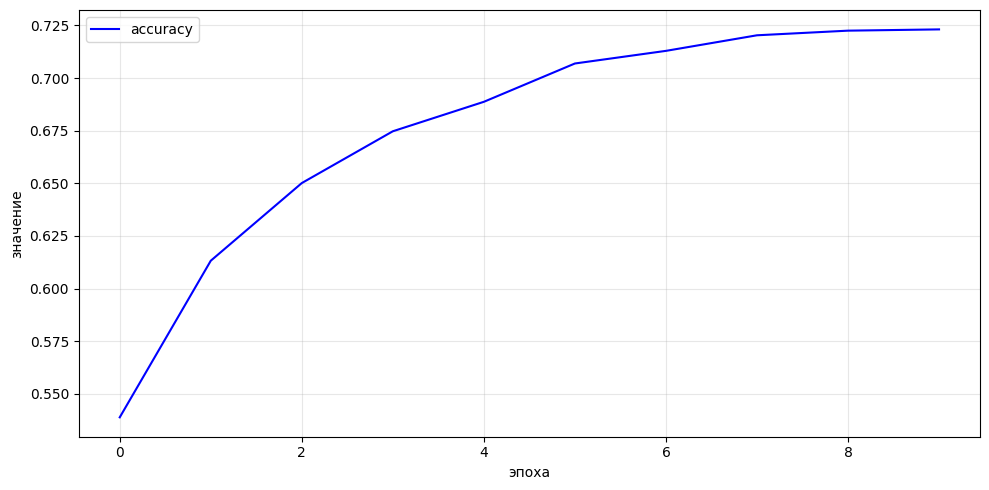

In [9]:
loss_graph(range(EPOCHS), arr_of_train_loss, arr_of_val_loss)
metric_graph(range(EPOCHS), arr_of_acc)

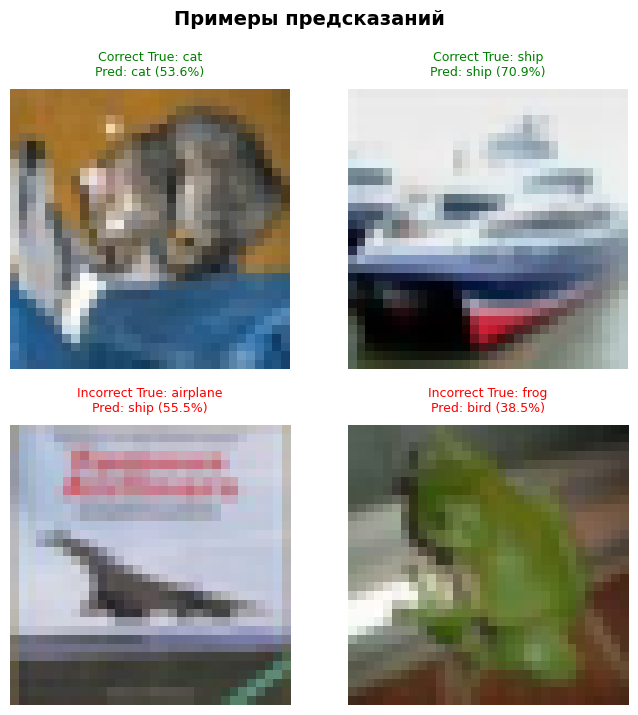

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
fig.suptitle(f'Примеры предсказаний', fontsize=14, fontweight='bold')

for i, (img, t, p, logit) in enumerate(correct_examples):
    plot_example(axes[0, i], img, t, p, logit, is_correct=True)

for i, (img, t, p, logit) in enumerate(incorrect_examples):
    plot_example(axes[1, i], img, t, p, logit, is_correct=False)